Aqui vamos a llamar a todos lo imports para que no tengas que hacer el proceso a cada rato :

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

EJERCICIO 1

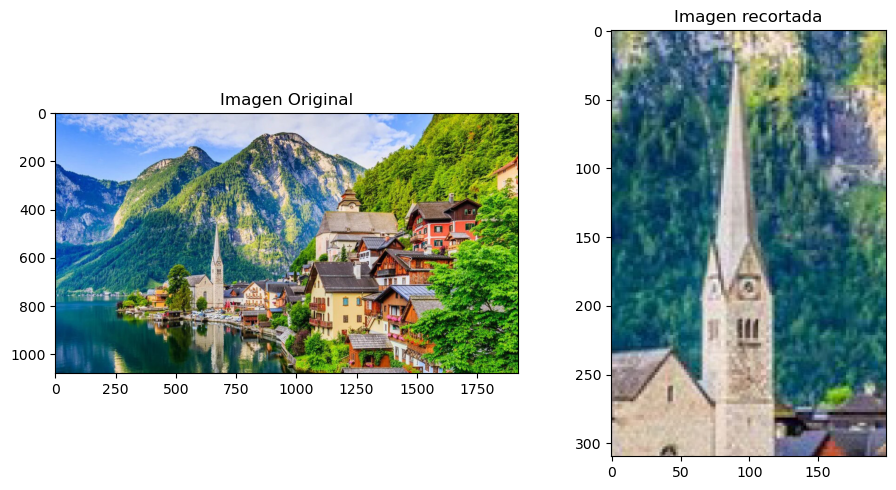

In [93]:
img_p = cv2.imread('imagenP.jpg.jpeg')
img_p_rgb = cv2.cvtColor(img_p, cv2.COLOR_BGR2RGB)

y_inicio, y_fin = 440, 750
x_inicio, x_fin = 580, 780
img_recortada = img_p_rgb[y_inicio:y_fin, x_inicio:x_fin]

cv2.imwrite('recorte_ejercicio1.jpg', cv2.cvtColor(img_recortada, cv2.COLOR_RGB2BGR))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img_p_rgb)
axs[0].set_title('Imagen Original')

axs[1].imshow(img_recortada)
axs[1].set_title('Imagen recortada')

plt.tight_layout()
plt.show()

Ejercicio 2

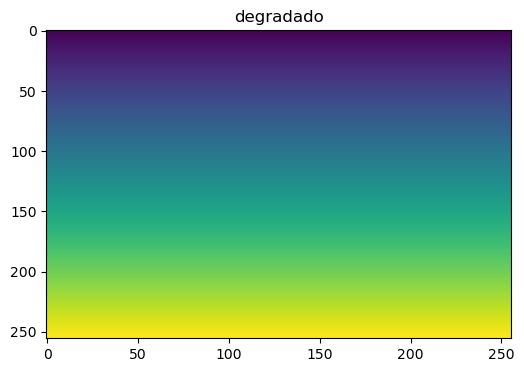

True

In [94]:
degradado_gris = np.linspace(0, 255, 256, dtype=np.uint8)
degradado_2d = np.tile(degradado_gris, (256, 1)).T

plt.figure(figsize=(6, 4))
plt.imshow(degradado_2d, cmap='viridis', aspect='auto')
plt.title('degradado')
plt.show()

cv2.imwrite('degradado_base.jpg', degradado_2d)

EJERCICIO 3

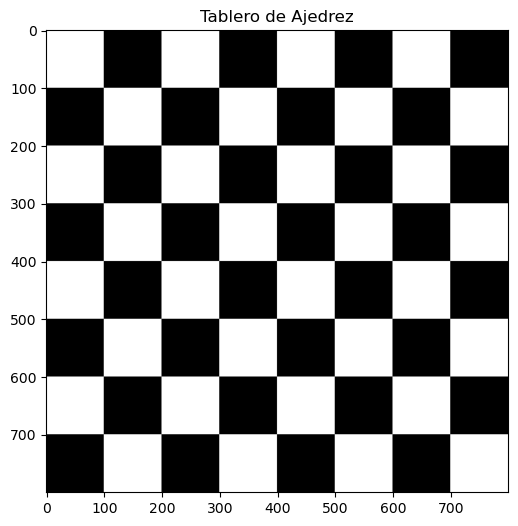

True

In [95]:
casilla = 100
filas, columnas = 8, 8

tablero = np.zeros((filas * casilla, columnas * casilla), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        if (i + j) % 2 == 0:
            tablero[i*casilla:(i+1)*casilla, j*casilla:(j+1)*casilla] = 255

plt.figure(figsize=(6,6))
plt.imshow(tablero, cmap='gray')
plt.title('Tablero de Ajedrez')
plt.show()

cv2.imwrite('tablero_ajedres.jpg', tablero)

EJERCICIO 4

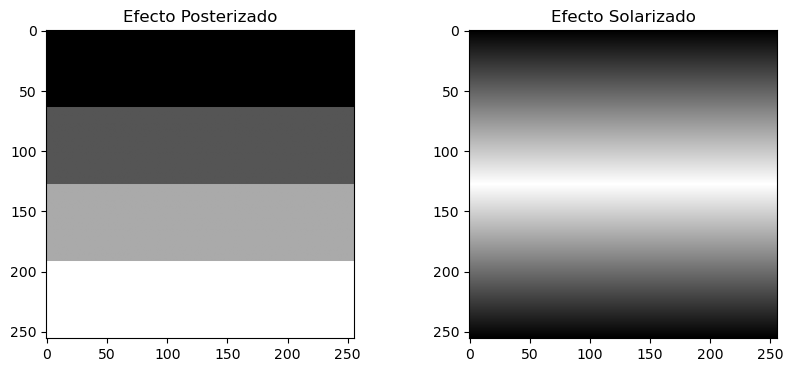

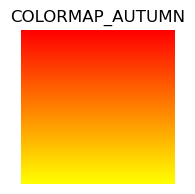

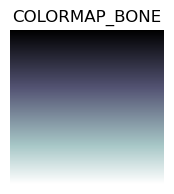

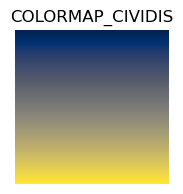

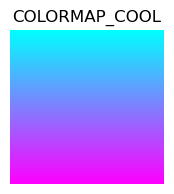

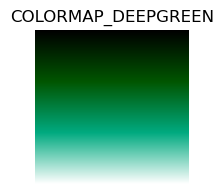

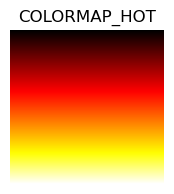

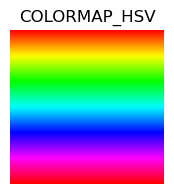

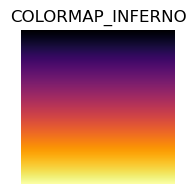

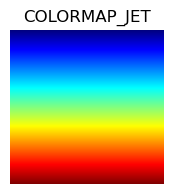

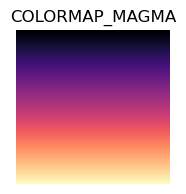

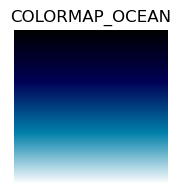

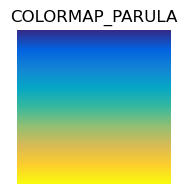

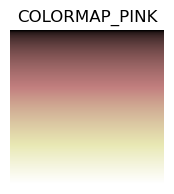

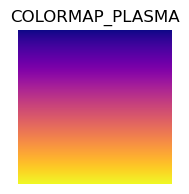

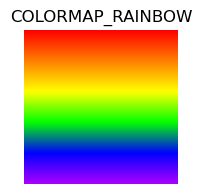

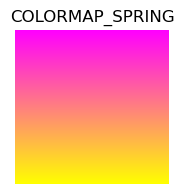

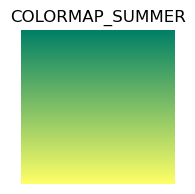

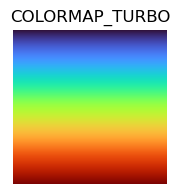

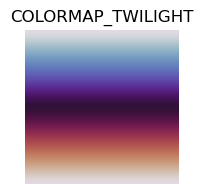

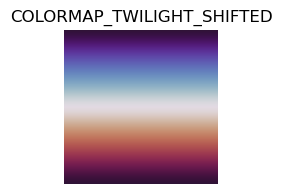

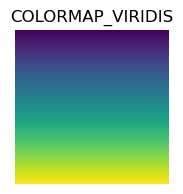

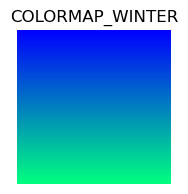

In [104]:
base_tmp = np.linspace(0, 255, 256, dtype=np.uint8)
mi_img = np.tile(base_tmp, (256, 1)).T

n_bits = 64
img_post_final = (mi_img // n_bits) * n_bits

umbral_val = 127
img_sol_final = np.where(mi_img > umbral_val, 255 - mi_img, mi_img).astype(np.uint8)

cv2.imwrite('res_posterizado.jpg', img_post_final)
cv2.imwrite('res_solarizado.jpg', img_sol_final)

fig_2, array_plots = plt.subplots(1, 2, figsize=(10, 4))
array_plots[0].imshow(img_post_final, cmap='gray')
array_plots[0].set_title('Efecto Posterizado')
array_plots[1].imshow(img_sol_final, cmap='gray')
array_plots[1].set_title('Efecto Solarizado')
plt.show()

todos_los_mapas = [atributo for atributo in dir(cv2) if atributo.startswith('COLORMAP_')]

for m_name in todos_los_mapas:
    map_code = getattr(cv2, m_name)
    img_coloreada = cv2.applyColorMap(mi_img, map_code)
    
    cv2.imwrite(f'falso_{m_name}.jpg', img_coloreada)
    
    plt.figure(figsize=(4, 2))
    plt.imshow(cv2.cvtColor(img_coloreada, cv2.COLOR_BGR2RGB))
    plt.title(m_name)
    plt.axis('off')
    plt.show()

ejercicio 5

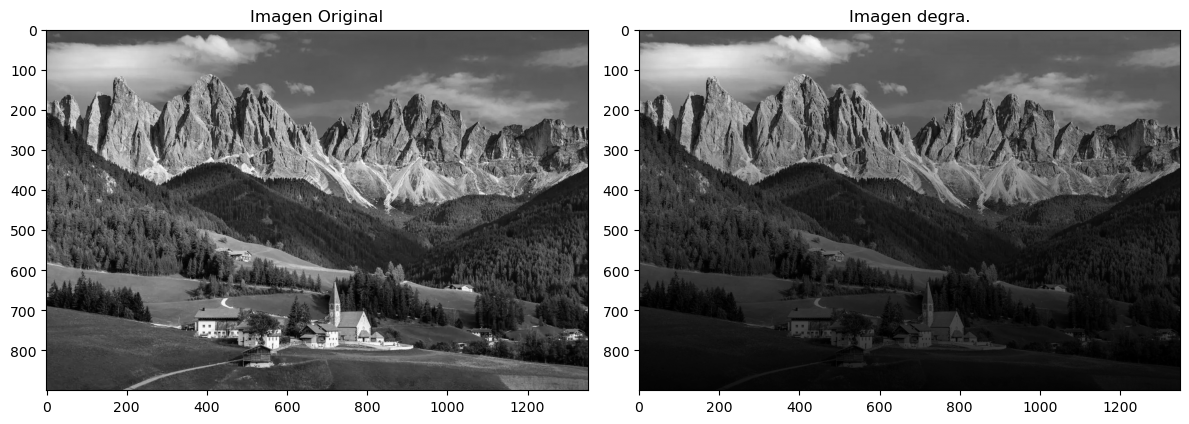

In [ ]:
img_paisaje = cv2.imread('imagen1.jpg.jpeg', cv2.IMREAD_GRAYSCALE)

if img_paisaje is not None:
    h, w = img_paisaje.shape
    
    vector_degradado = np.linspace(1.0, 0.1, h).reshape(-1, 1)
    mascara_degradado = np.tile(vector_degradado, (1, w))
    
    img_con_degradado = (img_paisaje * mascara_degradado).astype(np.uint8)
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(img_paisaje, cmap='gray')
    axs[0].set_title('ImagenOriginal')
    
    axs[1].imshow(img_con_degradado, cmap='gray')
    axs[1].set_title('Imagen degra.')
    
    plt.tight_layout()
    plt.show()
    
    cv2.imwrite('paisaje_degradado.jpg', img_con_degradado)

ejercicio 6

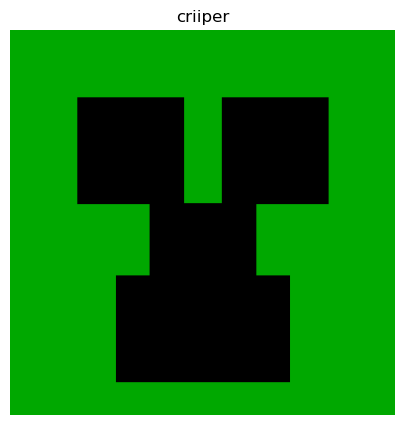

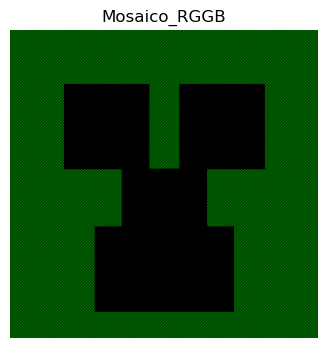

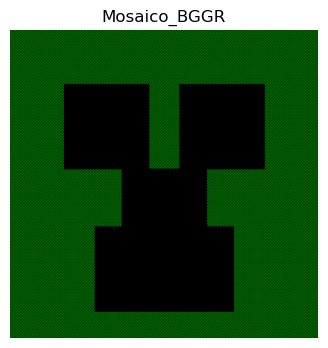

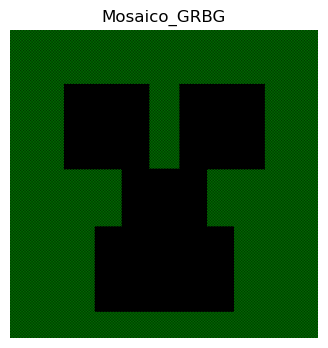

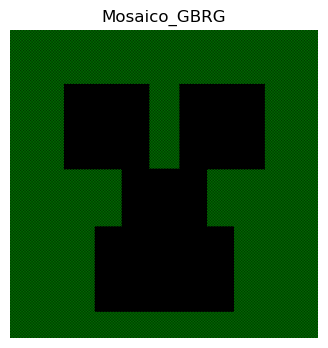

In [111]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

lienzo = 400
img_perfecta = np.zeros((lienzo, lienzo, 3), dtype=np.uint8)

verde_mc = (0, 168, 0)
negro_mc = (0, 0, 0)

cv2.rectangle(img_perfecta, (0, 0), (400, 400), verde_mc, -1)

cv2.rectangle(img_perfecta, (70, 70), (180, 180), negro_mc, -1)
cv2.rectangle(img_perfecta, (220, 70), (330, 180), negro_mc, -1)

cv2.rectangle(img_perfecta, (145, 180), (255, 365), negro_mc, -1)
cv2.rectangle(img_perfecta, (110, 255), (145, 365), negro_mc, -1)
cv2.rectangle(img_perfecta, (255, 255), (290, 365), negro_mc, -1)

plt.figure(figsize=(5, 5))
plt.imshow(img_perfecta)
plt.title("criiper")
plt.axis('off')
plt.show()

def aplicar_mosaico_bayer(img, patron_b):
    salida_m = np.zeros_like(img)
    for f in range(2):
        for c in range(2):
            ch = patron_b[f][c]
            salida_m[f::2, c::2, ch] = img[f::2, c::2, ch]
    return salida_m

modelos_bayer = {
    'Mosaico_RGGB': [[0, 1], [1, 2]],
    'Mosaico_BGGR': [[2, 1], [1, 0]],
    'Mosaico_GRBG': [[1, 0], [2, 1]],
    'Mosaico_GBRG': [[1, 2], [0, 1]]
}

for desc, p_mat in modelos_bayer.items():
    img_mosaico = aplicar_mosaico_bayer(img_perfecta, p_mat)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_mosaico)
    plt.title(f"{desc}")
    plt.axis('off')
    plt.show()
    
    cv2.imwrite(f'final_bayer_{desc}.jpg', cv2.cvtColor(img_mosaico, cv2.COLOR_RGB2BGR))